# Column Descriptions

**Numerical Columns**

1. **id** – Unique id for each patient  
2. **age** – Age of the patient in years  
3. **trestbps** – Resting blood pressure in mm Hg  
4. **chol** – Serum cholesterol in mg/dl  
5. **thalach** – Maximum heart rate achieved  
6. **oldpeak** – ST depression induced by exercise relative to rest  
7. **ca** – Number of major vessels (0–3) colored by fluoroscopy  

**Ordinal Columns**

8. **cp** – Chest pain type: typical angina < atypical angina < non-anginal < asymptomatic  
9. **slope** – Slope of the peak exercise ST segment: upsloping < flat < downsloping  
10. **thal** – Heart defect: normal < fixed defect < reversible defect  

**Nominal Columns**

11. **origin** – Place of study  
12. **sex** – Male/Female  
13. **fbs** – Fasting blood sugar > 120 mg/dl  
14. **restecg** – Resting electrocardiographic results: normal, stt abnormality, lv hypertrophy  
15. **exang** – Exercise-induced angina: True/False  

**Target**

16. **num** – Predicted attribute (0–4) depending on severity

# Initialization

## Libraries

In [1]:
%pip install phik
%pip install gdown


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from ml.preprocessing import *

import os
import math
from pathlib import Path
import joblib

import gdown

from sklearn.ensemble import (
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    RandomizedSearchCV,
    train_test_split,
    cross_val_score
)
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder,
    FunctionTransformer,
    PowerTransformer
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.compose import ColumnTransformer

from xgboost import XGBClassifier

import numpy as np
import pandas as pd
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import phik

from scipy.stats import uniform, randint, loguniform

## Constants

In [3]:
GOOGLE_DRIVE_FILE_URL = "https://drive.google.com/uc?id=1iNQ1Fy-0LQjktOeNBLv1N4TxqM_Snkfo"
CSV_PATH_STR = Path("datasets/heart_disease_uci.csv")

SEED = 42
TEST_PERCENT = 0.2

THALACH_BINS = [0, 150, np.inf]
THALACH_LABELS = ['Low', 'High']

TARGET_COL = "num"

## Helper Methods

In [ ]:
def load_drive_csv_data(url=GOOGLE_DRIVE_FILE_URL, csv_path_str=CSV_PATH_STR):
    csv_path = Path(csv_path_str)

    if not csv_path.exists():
        csv_path.parent.mkdir(parents=True, exist_ok=True)
        gdown.download(url, str(csv_path), quiet=False)

    df = pd.read_csv(csv_path)
    return df

In [5]:
def num_cat_split(df, ratio_threshold=0.05):
    num_cols = []
    cat_cols = []
    for col in df.columns:
        n_unique = df[col].nunique()
        ratio = n_unique / len(df)

        # Determine column type
        if ratio <= ratio_threshold:
            cat_cols.append(col)
        else:
            num_cols.append(col)
    return num_cols, cat_cols

In [6]:
def countplot_grid(df, n_cols=2, figsize_per_plot=(12,8),
                          label_size=18, tick_size=18, **plot_args):
    num_features = len(df.columns)
    n_rows = math.ceil(num_features / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(figsize_per_plot[0]*n_cols, figsize_per_plot[1]*n_rows))
    axes = axes.flatten()

    for i, col in enumerate(df.columns):
        sns.countplot(data=df, x=col, ax=axes[i], **plot_args)
        axes[i].set_xlabel(col, fontsize=label_size * 2)
        axes[i].set_ylabel('Count', fontsize=label_size)
        axes[i].tick_params(axis='x', labelsize=tick_size * 1.25)
        axes[i].tick_params(axis='y', labelsize=tick_size * 1.25)

    # Remove empty subplots
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

def visualize_matrix(matrix, title, cmap='viridis'):
  plt.figure(figsize=(10, 8))

  sns.heatmap(matrix,
              annot=True,
              cmap=cmap,
              fmt=".2f",
              vmin=-1, vmax=1,
              square=True)

  plt.title(title)
  plt.show()

In [7]:
def print_col_percentage(df, col):
  print(df[col].value_counts() / len(df))

In [8]:
def clean_params(params):
    return {k.replace('model__', ''): v for k, v in params.items()}

In [9]:
def evaluate_model(model, x, y):
    y_pred = model.predict(x)

    acc = accuracy_score(y, y_pred)
    cm = confusion_matrix(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)

    print(f"Accuracy        : {acc:.4f}")
    print(f"Precision       : {precision:.4f}")
    print(f"Recall          : {recall:.4f}")
    print(f"F1 Score        : {f1:.4f}")

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Greens)
    plt.title("Confusion Matrix")
    plt.show()


def cross_validate_model(model, x, y):
    scores = cross_validate(
        model,
        x,
        y,
        cv=10,
        scoring={
            'accuracy': 'accuracy',
            'precision': 'precision',
            'recall': 'recall',
            'f1': 'f1'
        }
    )

    print(f"CV Mean Accuracy: {scores['test_accuracy'].mean():.4f}")
    print(f"CV Mean Precision: {scores['test_precision'].mean():.4f}")
    print(f"CV Mean Recall: {scores['test_recall'].mean():.4f}")
    print(f"CV Mean F1 Score: {scores['test_f1'].mean():.4f}")

In [10]:
def print_col_counts(df):
    for col in df.columns:
        print(f"Column: {col}")
        print(df[col].value_counts(dropna=False))
        print("-" * 30)

# Data Preperation

## Data Loading

In [11]:
dataset = load_drive_csv_data()

# Binary Classifier
dataset['num'] = (dataset['num'] > 0).astype(int)
dataset.drop(columns=['id', 'dataset'], inplace=True)
dataset.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Data Splitting

### Train/Test Split

In [12]:
dataset["stratify_col"] = (
    dataset["num"].astype(str)
    + "_" + dataset["cp"].astype(str)
)

dataset['stratify_col'].value_counts()

train, test = train_test_split(
    dataset,
    test_size=TEST_PERCENT,
    random_state=SEED,
    stratify=dataset["stratify_col"]
)

print_col_percentage(train, 'cp')
print_col_percentage(test, 'cp')

print_col_percentage(train, 'num')
print_col_percentage(test, 'num')

for df in [dataset, train, test]:
    df.drop(columns=["stratify_col"], inplace=True)

cp
asymptomatic       0.539402
non-anginal        0.221467
atypical angina    0.188859
typical angina     0.050272
Name: count, dtype: float64
cp
asymptomatic       0.538043
non-anginal        0.222826
atypical angina    0.190217
typical angina     0.048913
Name: count, dtype: float64
num
1    0.552989
0    0.447011
Name: count, dtype: float64
num
1    0.554348
0    0.445652
Name: count, dtype: float64


### Feature/Target Split

In [13]:
train_x = train.drop(columns=[TARGET_COL])
train_y = train[TARGET_COL]

test_x = test.drop(columns=[TARGET_COL])
test_y = test[TARGET_COL]

### Numerical/Categorical Split

In [14]:
num_cols, cat_cols = num_cat_split(train)

print(f"Num cols: {num_cols}")
print(f"Cat cols: {cat_cols}")

train_cat_cols = cat_cols.copy()
train_cat_cols.remove('num')

extracted_features = ['age_thalch', 'stress_index','bp_age', 'metabolic_risk']

train_num_cols = num_cols + extracted_features

skewed_train_num_cols = ['oldpeak', 'chol', 'stress_index', 'trestbps']
normal_train_num_cols = [col for col in train_num_cols if col not in skewed_train_num_cols]

one_hot_cols = ['restecg', 'sex', 'fbs', 'exang']

ordinal_cols = ['cp', 'slope', 'thal', 'ca']
ordinal_categories = [
    ['non-anginal', 'atypical angina', 'typical angina', 'asymptomatic'],
    ['upsloping', 'flat', 'downsloping'],
    ['normal', 'reversable defect','fixed defect'],
    [0.0, 1.0, 2.0, 3.0, 4.0]
]

train_num = train[num_cols]
train_cat = train[cat_cols]

test_num = test[num_cols]
test_cat = test[cat_cols]

Num cols: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
Cat cols: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'num']


In [15]:
print_col_counts(train_cat)

Column: sex
sex
Male      583
Female    153
Name: count, dtype: int64
------------------------------
Column: cp
cp
asymptomatic       397
non-anginal        163
atypical angina    139
typical angina      37
Name: count, dtype: int64
------------------------------
Column: fbs
fbs
False    553
True     117
NaN       66
Name: count, dtype: int64
------------------------------
Column: restecg
restecg
normal              433
lv hypertrophy      154
st-t abnormality    148
NaN                   1
Name: count, dtype: int64
------------------------------
Column: exang
exang
False    425
True     263
NaN       48
Name: count, dtype: int64
------------------------------
Column: slope
slope
flat           283
NaN            249
upsloping      155
downsloping     49
Name: count, dtype: int64
------------------------------
Column: ca
ca
NaN    493
0.0    136
1.0     52
2.0     37
3.0     18
Name: count, dtype: int64
------------------------------
Column: thal
thal
NaN                  392
normal   

# Data Exploration

## Overview

In [16]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 736 entries, 290 to 760
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       736 non-null    int64  
 1   sex       736 non-null    object 
 2   cp        736 non-null    object 
 3   trestbps  684 non-null    float64
 4   chol      711 non-null    float64
 5   fbs       670 non-null    object 
 6   restecg   735 non-null    object 
 7   thalch    688 non-null    float64
 8   exang     688 non-null    object 
 9   oldpeak   684 non-null    float64
 10  slope     487 non-null    object 
 11  ca        243 non-null    float64
 12  thal      344 non-null    object 
 13  num       736 non-null    int64  
dtypes: float64(5), int64(2), object(7)
memory usage: 86.2+ KB


In [17]:
train_num.describe()

,age,trestbps,chol,thalch,oldpeak
count,736.000000,684.000000,711.000000,688.000000,684.000000
mean,53.611413,132.176901,201.790436,137.257267,0.871637
std,9.295370,19.200552,111.279345,25.681666,1.091676
min,29.000000,0.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,177.000000,120.000000,0.000000
50%,54.000000,130.000000,225.000000,140.000000,0.500000
75%,60.000000,140.000000,269.000000,157.000000,1.500000
max,77.000000,200.000000,603.000000,202.000000,6.200000


In [18]:
train_num.skew()

age        -0.193555
trestbps    0.183962
chol       -0.586156
thalch     -0.216444
oldpeak     1.065566
dtype: float64

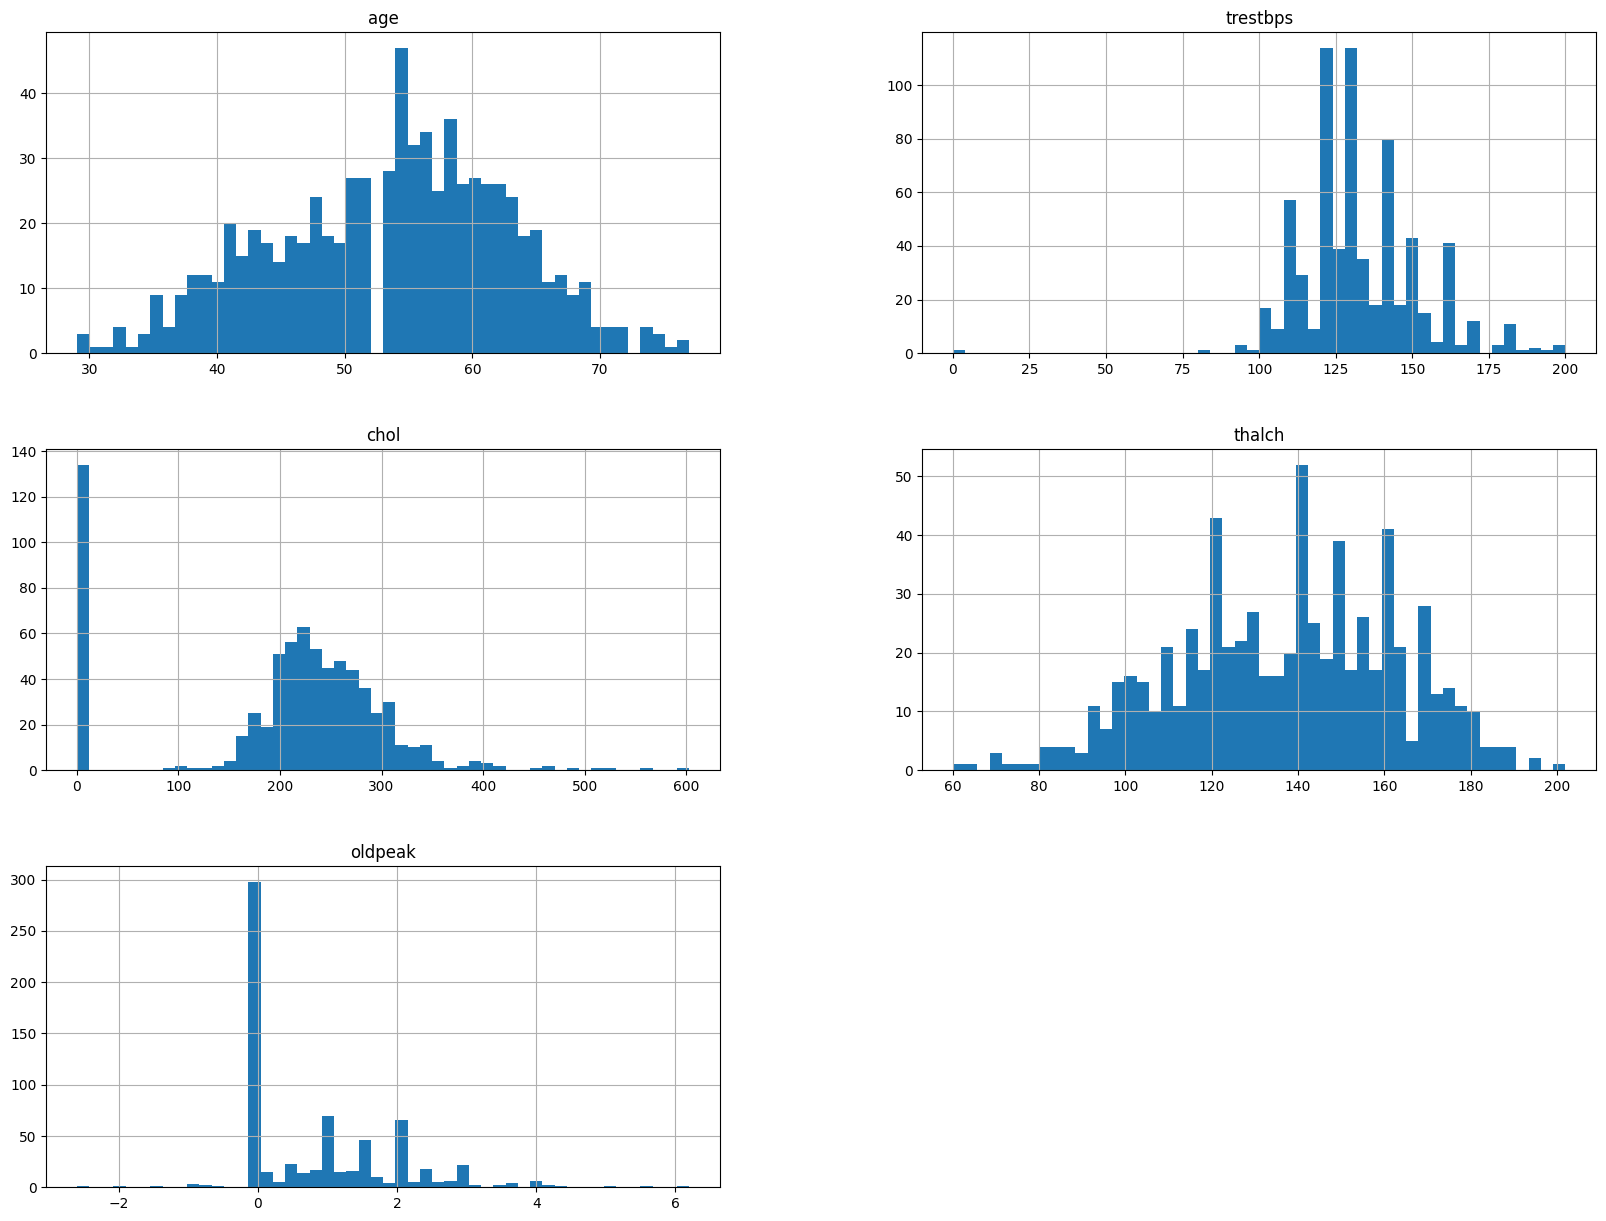

In [19]:
train_num.hist(bins=50, figsize=(20,15))
plt.show()


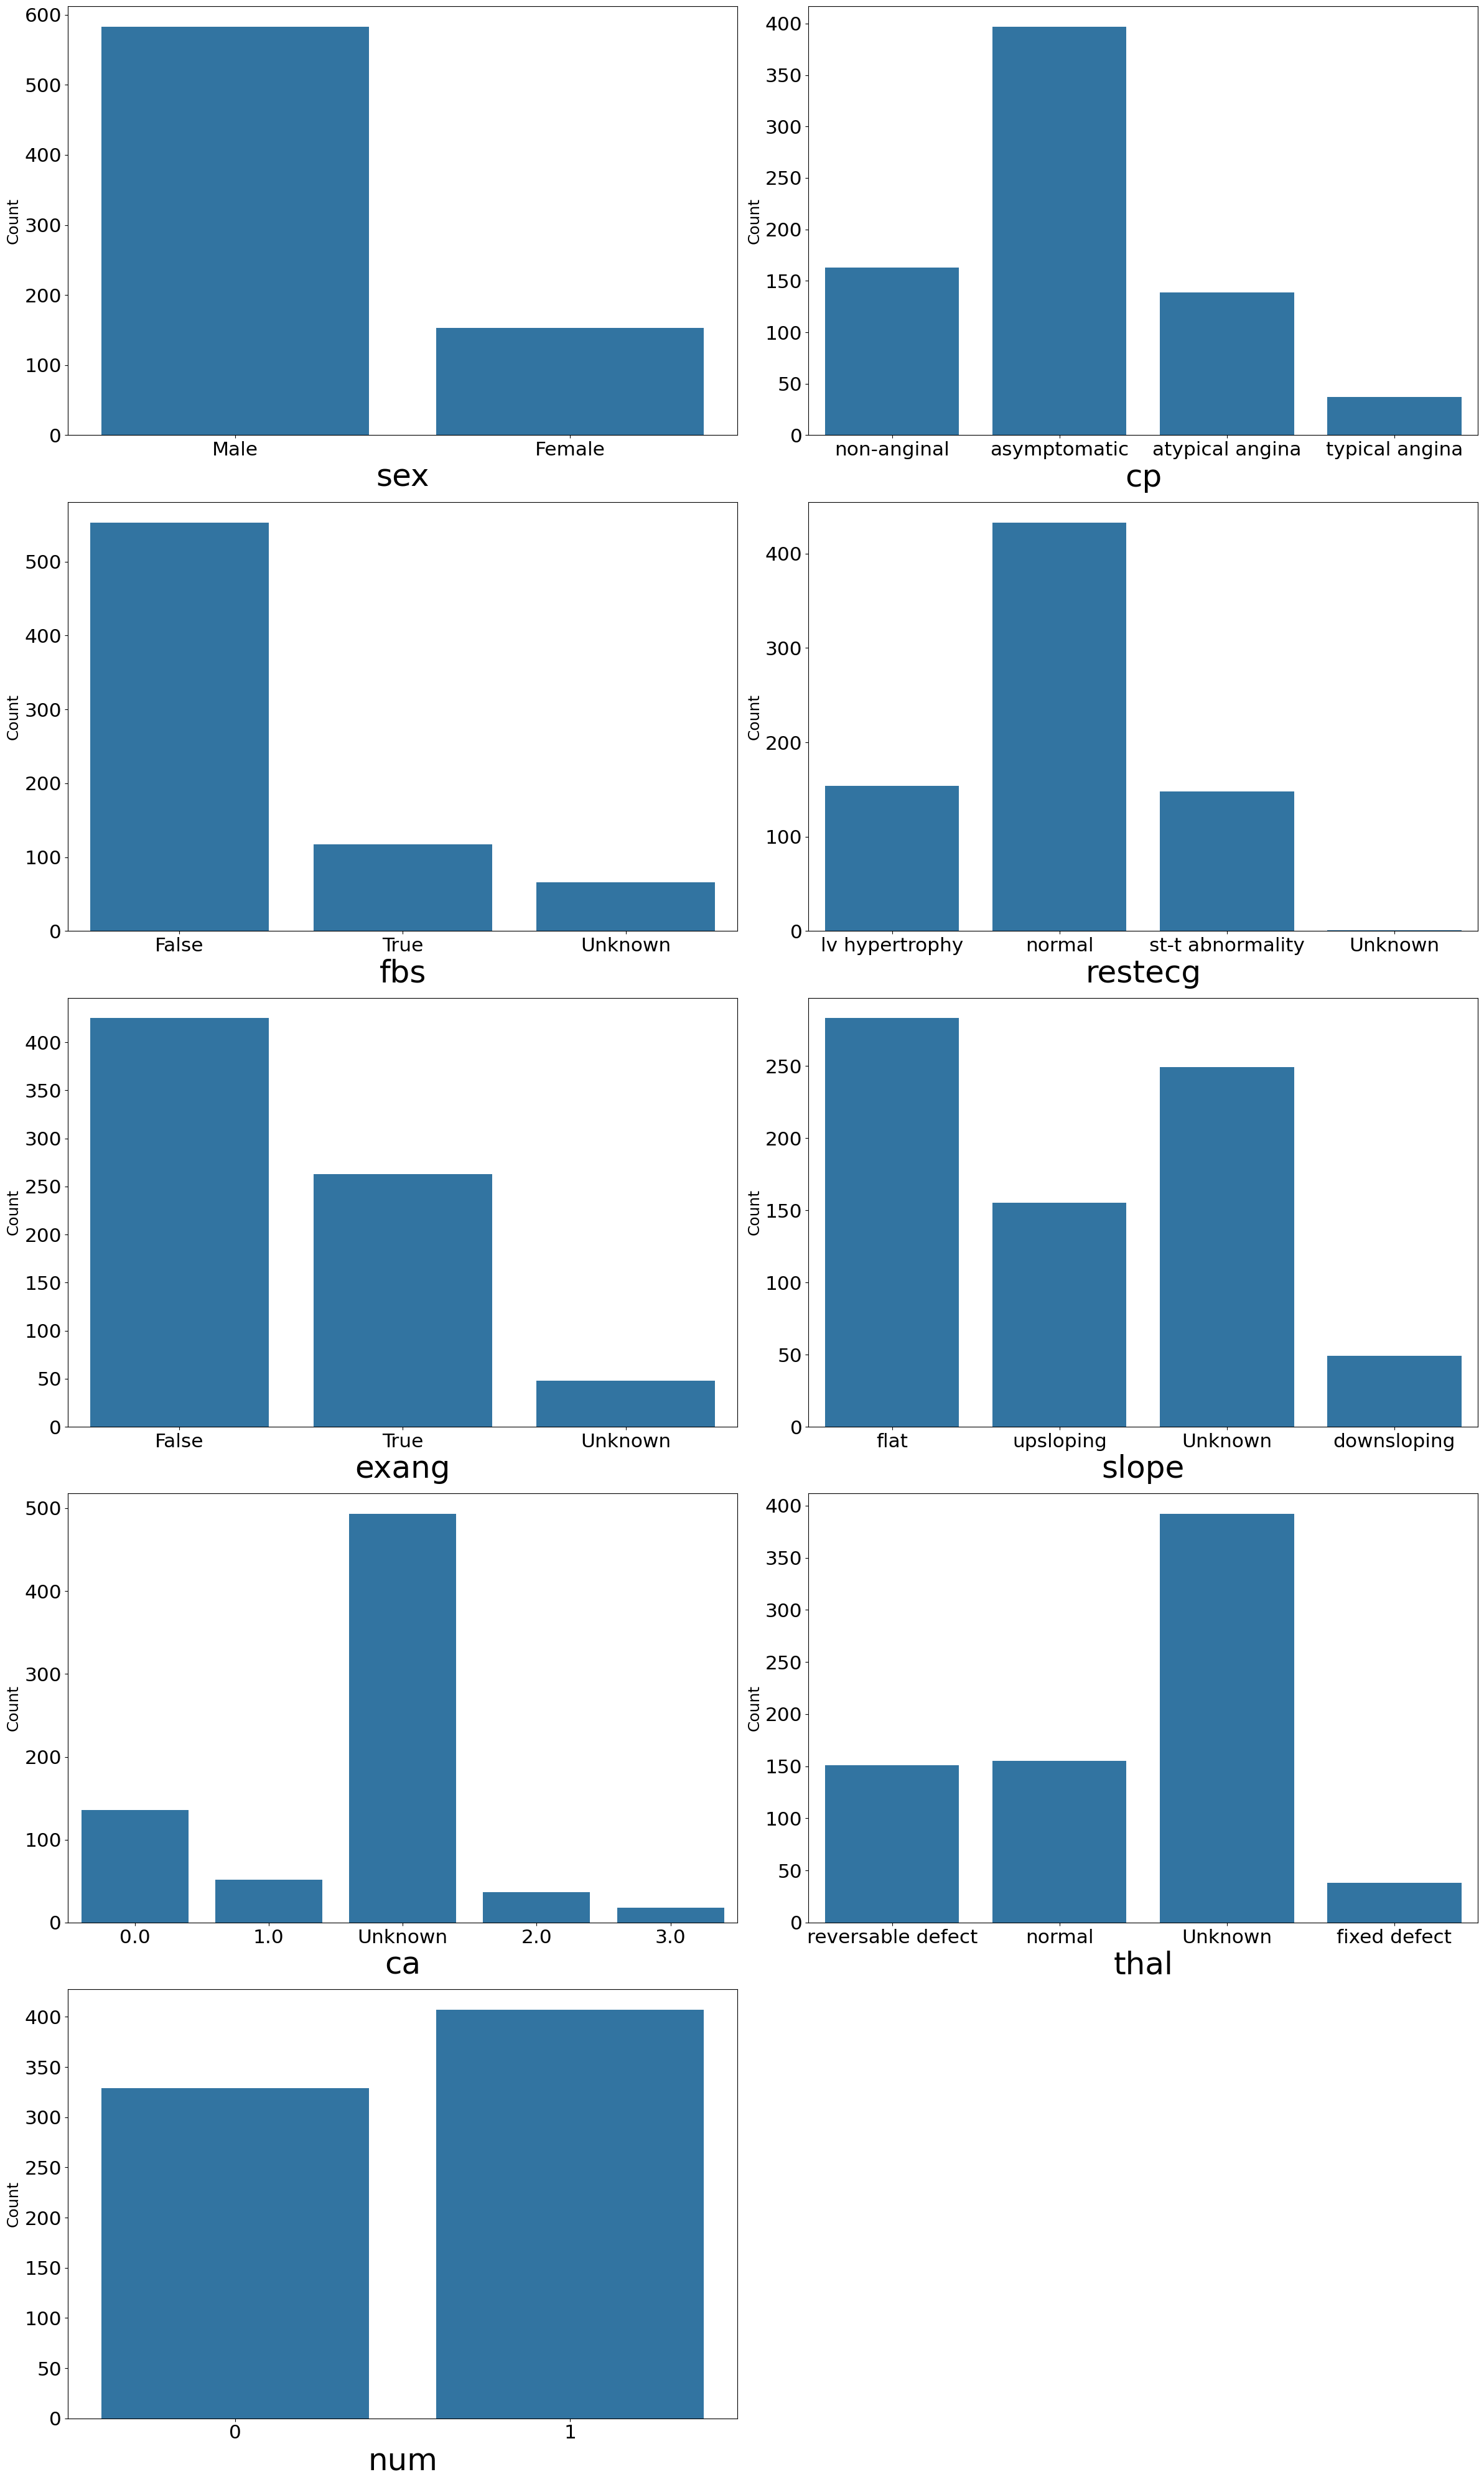

In [20]:
countplot_grid(train_cat.fillna('Unknown'))

## Correlation

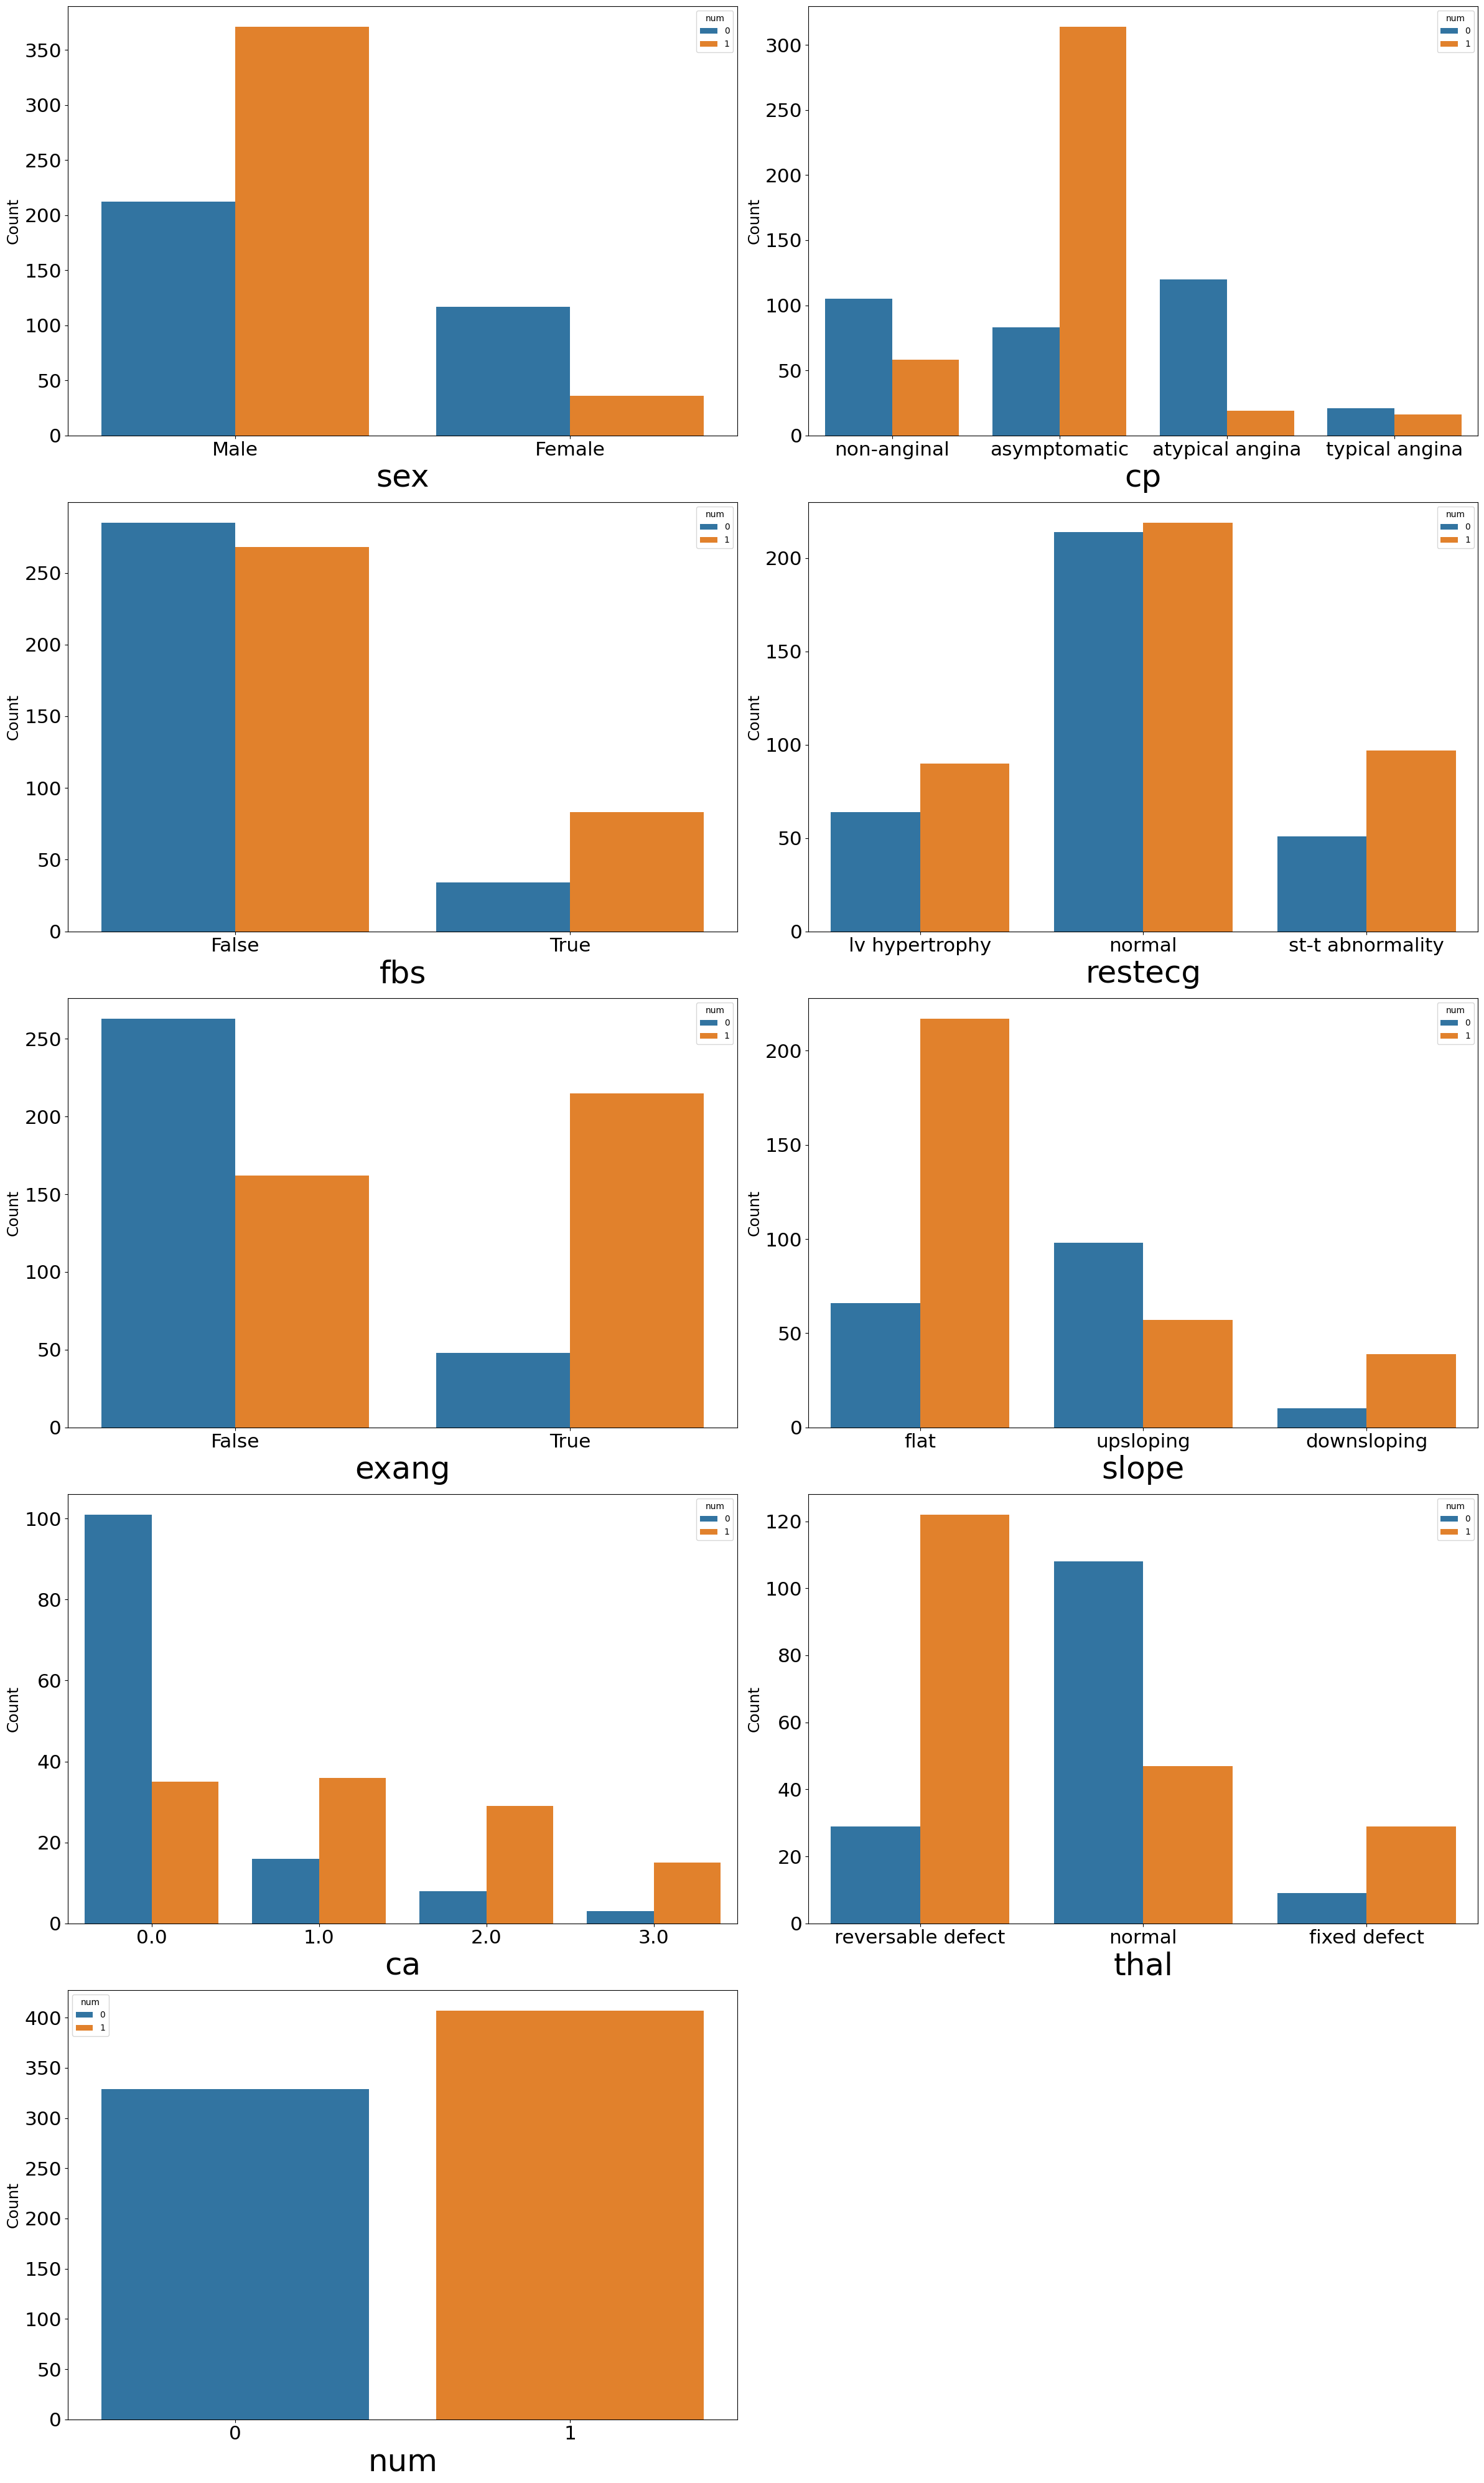

In [21]:
countplot_grid(train_cat, hue=TARGET_COL)

array([[<Axes: xlabel='age', ylabel='age'>,
        <Axes: xlabel='trestbps', ylabel='age'>,
        <Axes: xlabel='chol', ylabel='age'>,
        <Axes: xlabel='thalch', ylabel='age'>,
        <Axes: xlabel='oldpeak', ylabel='age'>],
       [<Axes: xlabel='age', ylabel='trestbps'>,
        <Axes: xlabel='trestbps', ylabel='trestbps'>,
        <Axes: xlabel='chol', ylabel='trestbps'>,
        <Axes: xlabel='thalch', ylabel='trestbps'>,
        <Axes: xlabel='oldpeak', ylabel='trestbps'>],
       [<Axes: xlabel='age', ylabel='chol'>,
        <Axes: xlabel='trestbps', ylabel='chol'>,
        <Axes: xlabel='chol', ylabel='chol'>,
        <Axes: xlabel='thalch', ylabel='chol'>,
        <Axes: xlabel='oldpeak', ylabel='chol'>],
       [<Axes: xlabel='age', ylabel='thalch'>,
        <Axes: xlabel='trestbps', ylabel='thalch'>,
        <Axes: xlabel='chol', ylabel='thalch'>,
        <Axes: xlabel='thalch', ylabel='thalch'>,
        <Axes: xlabel='oldpeak', ylabel='thalch'>],
       [<Axes: xlab

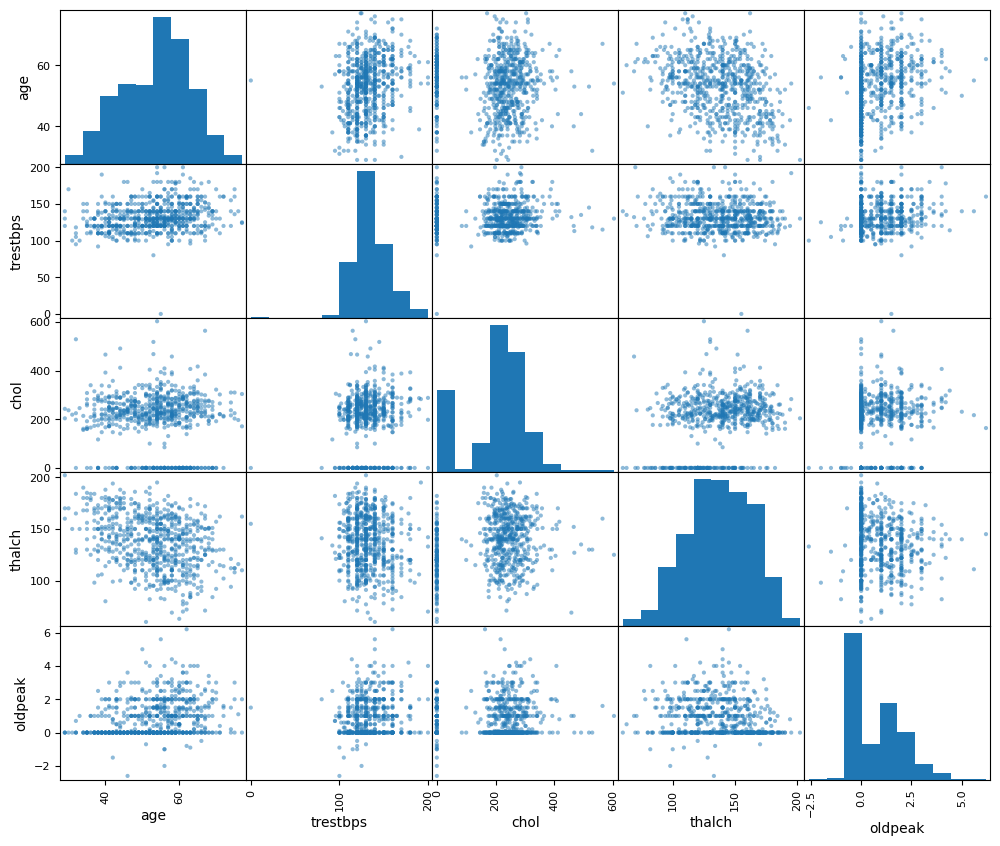

In [22]:
scatter_matrix(train_num, figsize=(12, 10))

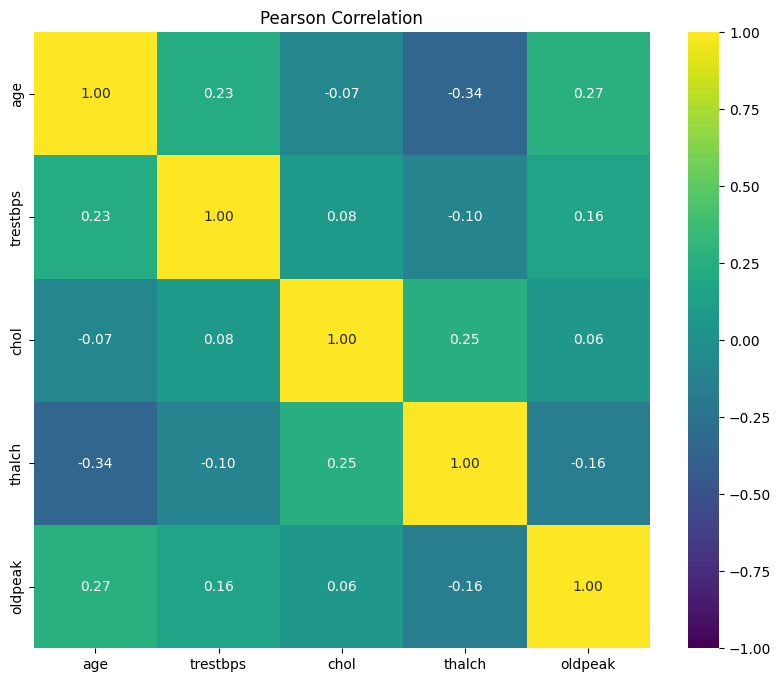

In [23]:
pearson_matrix = train_num.corr()
visualize_matrix(pearson_matrix, "Pearson Correlation")

interval columns not set, guessing: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num', 'metabolic_risk']


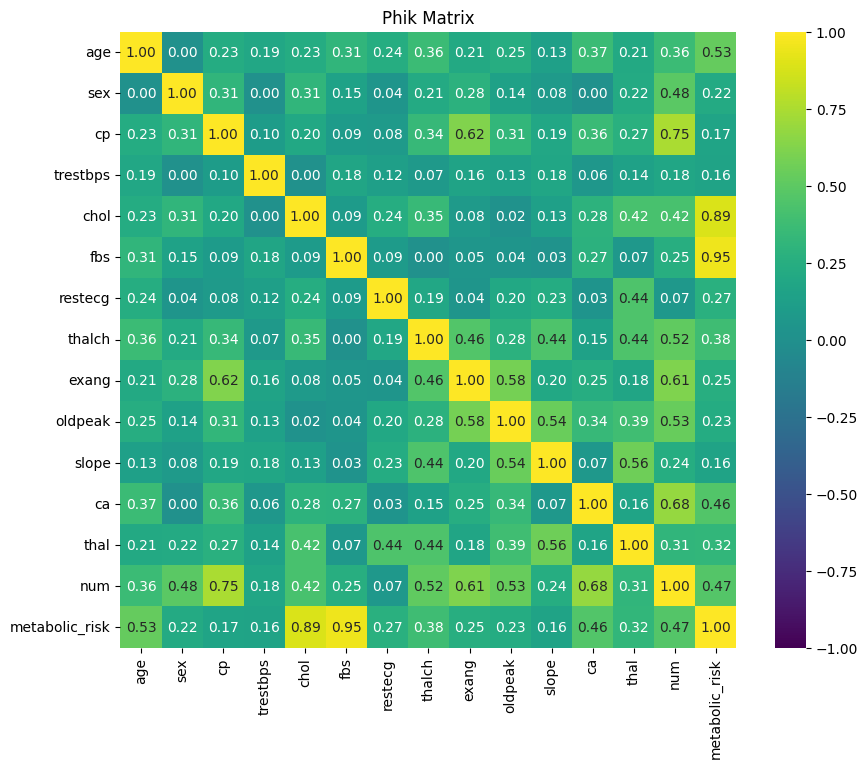

In [24]:
modified_train = train.copy()
modified_train['metabolic_risk'] = (
    (modified_train['chol']) *
    np.where(modified_train['fbs'] > 0, 2, 1) *
    (modified_train['age'])
)

phik_matrix = modified_train.phik_matrix()
visualize_matrix(phik_matrix, "Phik Matrix")

## Observations

- Dataset should be stratified by:
  -  num: ensures that the training data has the same proportions of the target value which avoid bia
  - cp: Strong predictor that needs to be represented accurately
- chol and oldpeak have a significant amount of values at 0, likely missing values.
- Irrelevant features:
  - id
  - sex
  - dataset
- Features with a large number of unknowns:
  - slope
  - ca
  - thal
- Right-skewed features
  - oldpeak
- Left-skewed features
  - chol
- Target classes are almost balanced, accuracy would be a suitable metric to evaluate models

# Preprocessing

## Numerical Pipeline

In [25]:
normal_num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

skewed_num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('power_tranformer', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])

## Categorical Pipeline

In [26]:
one_hot_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first')),
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=ordinal_categories)),
    ('scaler', StandardScaler())
])

## Preprocessing Pipeline

In [27]:
column_tranformer = ColumnTransformer([
    ('ordinal', ordinal_pipeline, ordinal_cols),
    ('one_hot', one_hot_pipeline, one_hot_cols),
    ('normal_num', normal_num_pipeline, normal_train_num_cols),
    ('skewed_num', skewed_num_pipeline, skewed_train_num_cols)
])

In [28]:
preprocessor = Pipeline([
    ('cleaning', cleaning_transformer),
    ('features', features_transformer),
    ('column_tranformor', column_tranformer)
])

preprocessor

Pipeline(steps=[('cleaning',
                 FunctionTransformer(feature_names_out='one-to-one',
                                     func=<function clean_data at 0x111835760>)),
                ('features',
                 FunctionTransformer(feature_names_out=<function feature_names_out at 0x111834720>,
                                     func=<function feature_engineering at 0x111835a80>)),
                ('column_tranformor',
                 ColumnTransformer(transformers=[('ordinal',
                                                  Pipeline(steps=[('imputer...
                                                 ('normal_num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'thalch',
                                                   'age_thalch', 'bp_age',
                                                   'metabolic_risk']),
                                                 ('skewed_num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('power_tranformer',
                                                                   PowerTransformer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['oldpeak', 'chol',
                                                   'stress_index',
                                                   'trestbps'])]))])

In [29]:
preprocessor.fit(train_x)

preprocessed_data = preprocessor.transform(train_x)
preprocessed_df = pd.DataFrame(
    preprocessed_data,
    columns=preprocessor.get_feature_names_out()
)
preprocessed_df.head()

,ordinal__cp,ordinal__slope,ordinal__thal,ordinal__ca,one_hot__restecg_normal,one_hot__restecg_st-t abnormality,one_hot__sex_Male,one_hot__fbs_True,one_hot__exang_True,normal_num__age,normal_num__thalch,normal_num__age_thalch,normal_num__bp_age,normal_num__metabolic_risk,skewed_num__oldpeak,skewed_num__chol,skewed_num__stress_index,skewed_num__trestbps
0,-1.505468,0.284408,1.229171,-0.372079,0.0,0.0,1.0,0.0,0.0,1.441330,0.506173,1.880559,1.831693,-0.145921,-1.254074,-0.641010,-1.469227,1.124054
1,0.862105,-1.690351,1.229171,1.149310,1.0,0.0,1.0,0.0,1.0,-0.173474,0.949341,0.765717,-0.251109,-0.275483,0.028621,0.270035,0.036302,-0.137794
2,0.862105,0.284408,1.229171,-0.372079,1.0,0.0,0.0,0.0,1.0,1.118369,0.103293,1.156377,1.184654,0.328959,-0.846283,0.657475,-0.974406,0.641372
3,0.862105,0.284408,1.229171,-0.372079,0.0,1.0,1.0,1.0,0.0,1.226022,-0.621891,0.472058,1.959211,-0.272189,0.028621,-0.027972,0.036302,1.473804
4,0.862105,0.284408,-0.548176,1.149310,0.0,0.0,1.0,1.0,1.0,0.257140,0.264445,0.561086,-0.048024,1.732187,-0.474468,0.153115,-0.673305,-0.323420


# Model Training

## Random Forest Pipeline

In [30]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=SEED))
])

## Logistic Regression Pipeline

In [31]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=SEED))
])

## XGBoost Pipeline

In [32]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(random_state=SEED))
])

## Results Without Fine-Tuning

In [33]:
cross_validate_model(rf_pipeline, train_x, train_y)

CV Mean Accuracy: 0.8028
CV Mean Precision: 0.8093
CV Mean Recall: 0.8448
CV Mean F1 Score: 0.8258


In [34]:
cross_validate_model(lr_pipeline, train_x, train_y)

CV Mean Accuracy: 0.8001
CV Mean Precision: 0.8170
CV Mean Recall: 0.8251
CV Mean F1 Score: 0.8195


In [35]:
cross_validate_model(xgb_pipeline, train_x, train_y)

CV Mean Accuracy: 0.7987
CV Mean Precision: 0.8033
CV Mean Recall: 0.8449
CV Mean F1 Score: 0.8228


# Fine Tuning

## Random Forest Fine-Tuning

In [36]:
param_dist_rf = {
    'model__n_estimators': [500],
    'model__max_features': ['sqrt'],
    'model__max_depth': [None, 5, 10, 15, 20, 25, 30],
    'model__min_samples_split': [2, 5, 10, 15, 20],
    'model__min_samples_leaf': [1, 2, 4, 8],
    'model__bootstrap': [True]
}

random_search_rf = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist_rf,
    n_iter=60,
    cv=10,
    scoring='recall',
    random_state=SEED,
)

random_search_rf.fit(train_x, train_y)

RandomizedSearchCV(cv=10,
                   estimator=Pipeline(steps=[('preprocessor',
                                              Pipeline(steps=[('cleaning',
                                                               FunctionTransformer(feature_names_out='one-to-one',
                                                                                   func=<function clean_data at 0x111835760>)),
                                                              ('features',
                                                               FunctionTransformer(feature_names_out=<function feature_names_out at 0x111834720>,
                                                                                   func=<function feature_engineering at 0x111835a80>)),
                                                              ('column_tranformor',
                                                               C...
                                                                                                 'stress_index',
                                                                                                 'trestbps'])]))])),
                                             ('model',
                                              RandomForestClassifier(random_state=42))]),
                   n_iter=60,
                   param_distributions={'model__bootstrap': [True],
                                        'model__max_depth': [None, 5, 10, 15,
                                                             20, 25, 30],
                                        'model__max_features': ['sqrt'],
                                        'model__min_samples_leaf': [1, 2, 4, 8],
                                        'model__min_samples_split': [2, 5, 10,
                                                                     15, 20],
                                        'model__n_estimators': [500]},
                   random_state=42, scoring='recall')

In [37]:
best_params_rf = random_search_rf.best_params_
clean_rf_params = clean_params(best_params_rf)

tuned_rf_model = random_search_rf.best_estimator_

print(clean_rf_params)

{'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': True}


## Logistic Regression Fine-Tuning

In [38]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=2000, random_state=SEED))
])

param_dist_lr = {
    'model__C': np.logspace(-3, 2, 20),   # 0.001 → 100
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs', 'liblinear'],
    'model__class_weight': [None, 'balanced']
}

random_search_lr = RandomizedSearchCV(
    lr_pipeline,
    param_distributions=param_dist_lr,
    n_iter=60,
    cv=10,
    scoring='recall',
    random_state=SEED,
)

random_search_lr.fit(train_x, train_y)

RandomizedSearchCV(cv=10,
                   estimator=Pipeline(steps=[('preprocessor',
                                              Pipeline(steps=[('cleaning',
                                                               FunctionTransformer(feature_names_out='one-to-one',
                                                                                   func=<function clean_data at 0x111835760>)),
                                                              ('features',
                                                               FunctionTransformer(feature_names_out=<function feature_names_out at 0x111834720>,
                                                                                   func=<function feature_engineering at 0x111835a80>)),
                                                              ('column_tranformor',
                                                               C...
       1.12883789e-02, 2.06913808e-02, 3.79269019e-02, 6.95192796e-02,
       1.27427499e-01, 2.33572147e-01, 4.28133240e-01, 7.84759970e-01,
       1.43844989e+00, 2.63665090e+00, 4.83293024e+00, 8.85866790e+00,
       1.62377674e+01, 2.97635144e+01, 5.45559478e+01, 1.00000000e+02]),
                                        'model__class_weight': [None,
                                                                'balanced'],
                                        'model__penalty': ['l2'],
                                        'model__solver': ['lbfgs',
                                                          'liblinear']},
                   random_state=42, scoring='recall')

In [39]:
best_params_lr = random_search_lr.best_params_
clean_lr_params = clean_params(best_params_lr)

tuned_lr_model = random_search_lr.best_estimator_

print(clean_lr_params)

{'solver': 'lbfgs', 'penalty': 'l2', 'class_weight': None, 'C': np.float64(0.001)}


## XGBoost Fine-Tuning

In [40]:
param_dist_xgb = {
    'model__n_estimators': [500],
    'model__max_depth': [3, 5, 7, 9],
    'model__learning_rate': [0.05],
    'model__gamma': [0, 0.1, 0.2, 0.3, 0.4],
    'model__subsample': [0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.7, 0.8, 0.9],
    'model__min_child_weight': [1, 3, 5],
    'model__reg_lambda': [1, 1.5, 2, 5]
}

random_search_xgb = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_dist_xgb,
    n_iter=60,
    cv=10,
    scoring='recall',
    random_state=SEED,
)

random_search_xgb.fit(train_x, train_y)

RandomizedSearchCV(cv=10,
                   estimator=Pipeline(steps=[('preprocessor',
                                              Pipeline(steps=[('cleaning',
                                                               FunctionTransformer(feature_names_out='one-to-one',
                                                                                   func=<function clean_data at 0x111835760>)),
                                                              ('features',
                                                               FunctionTransformer(feature_names_out=<function feature_names_out at 0x111834720>,
                                                                                   func=<function feature_engineering at 0x111835a80>)),
                                                              ('column_tranformor',
                                                               C...
                                                            num_parallel_tree=None, ...))]),
                   n_iter=60,
                   param_distributions={'model__colsample_bytree': [0.7, 0.8,
                                                                    0.9],
                                        'model__gamma': [0, 0.1, 0.2, 0.3, 0.4],
                                        'model__learning_rate': [0.05],
                                        'model__max_depth': [3, 5, 7, 9],
                                        'model__min_child_weight': [1, 3, 5],
                                        'model__n_estimators': [500],
                                        'model__reg_lambda': [1, 1.5, 2, 5],
                                        'model__subsample': [0.7, 0.8, 0.9]},
                   random_state=42, scoring='recall')

In [41]:
best_params_xgb = random_search_xgb.best_params_
clean_xgb_params = clean_params(best_params_xgb)

tuned_xgb_model = random_search_xgb.best_estimator_

print(clean_xgb_params)

{'subsample': 0.8, 'reg_lambda': 1.5, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.05, 'gamma': 0.4, 'colsample_bytree': 0.8}


# Final Model Evaluation

Accuracy        : 0.8261
Precision       : 0.8241
Recall          : 0.8725
F1 Score        : 0.8476


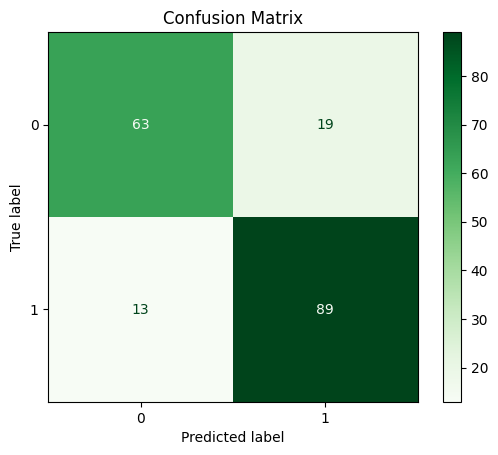

In [42]:
evaluate_model(tuned_rf_model, test_x, test_y)

Accuracy        : 0.7717
Precision       : 0.7500
Recall          : 0.8824
F1 Score        : 0.8108


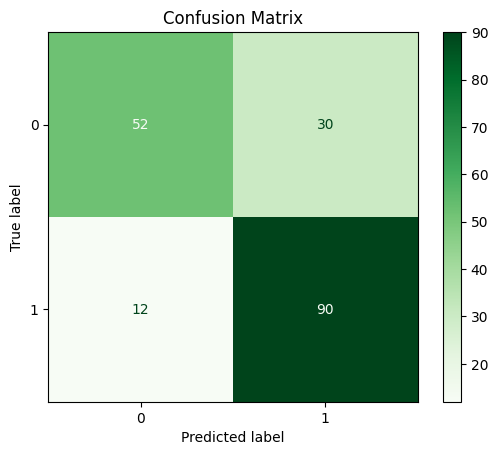

In [43]:
evaluate_model(tuned_lr_model, test_x, test_y)

Accuracy        : 0.8261
Precision       : 0.8302
Recall          : 0.8627
F1 Score        : 0.8462


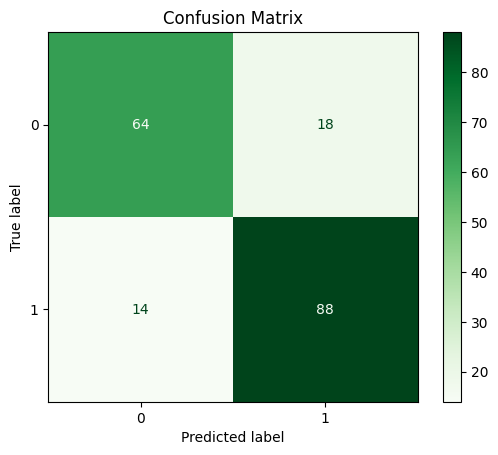

In [ ]:
evaluate_model(tuned_xgb_model, test_x, test_y)

# Persisting Final Models

In [ ]:
os.makedirs("models", exist_ok=True)

joblib.dump(tuned_rf_model, 'models/Random_Forest.pkl')
joblib.dump(tuned_lr_model, 'models/Logistic_Regression.pkl')
joblib.dump(tuned_xgb_model, 'models/XGBoost.pkl')

['models/XGBoost.pkl']